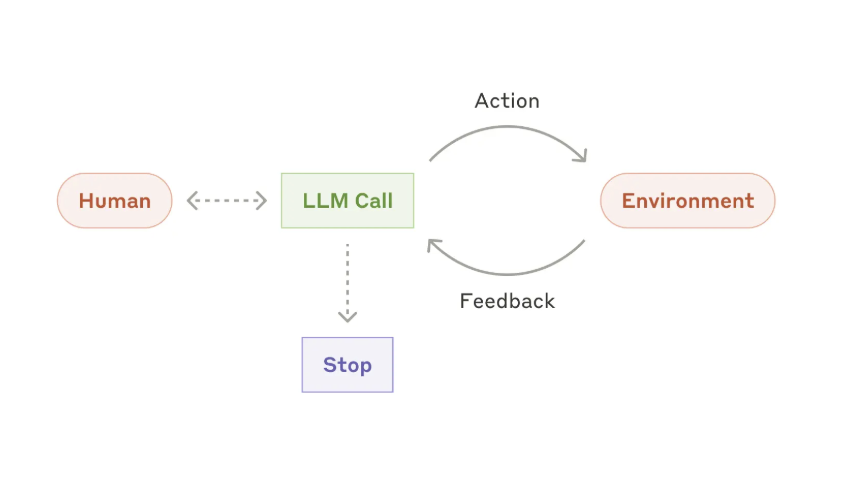

<a href="https://langchain-ai.github.io/langgraph/tutorials/workflows/">Source</a>

# 0.0. Configure

In [25]:
from dotenv import load_dotenv

In [26]:
load_dotenv()

True

# 1.0. Import

In [27]:
from IPython.display import Image, display
from langchain_core.tools import tool

from langgraph.graph import StateGraph, START, END
from IPython.display import Image, display
from langchain_openai import ChatOpenAI

from langgraph.graph import MessagesState
from langchain_core.messages import SystemMessage, HumanMessage, ToolMessage

from typing_extensions import Literal

# 2.0. Hands-On

In [28]:
@tool
def multiply(a: int, b: int) -> int:
    """Multiply a and b.

    Args:
        a: first int
        b: second int
    """
    return a * b

@tool
def add(a: int, b: int) -> int:
    """Adds a and b.

    Args:
        a: first int
        b: second int
    """
    return a + b

@tool
def divide(a: int, b: int) -> float:
    """Divide a and b.

    Args:
        a: first int
        b: second int
    """
    return a / b

In [29]:
tools = [add, multiply, divide]
tools_by_name = {tool.name: tool for tool in tools}

tools_by_name

{'add': StructuredTool(name='add', description='Adds a and b.\n\n    Args:\n        a: first int\n        b: second int', args_schema=<class 'pydantic.v1.main.addSchema'>, func=<function add at 0x7fe55c671a20>),
 'multiply': StructuredTool(name='multiply', description='Multiply a and b.\n\n    Args:\n        a: first int\n        b: second int', args_schema=<class 'pydantic.v1.main.multiplySchema'>, func=<function multiply at 0x7fe55c43a200>),
 'divide': StructuredTool(name='divide', description='Divide a and b.\n\n    Args:\n        a: first int\n        b: second int', args_schema=<class 'pydantic.v1.main.divideSchema'>, func=<function divide at 0x7fe55c671c60>)}

In [30]:
llm = ChatOpenAI(model="gpt-4o-mini")

llm_with_tools = llm.bind_tools(tools)

In [31]:
def llm_call(state: MessagesState):
    """LLM decides whether to call a tool or not"""

    return {
        "messages": [
            llm_with_tools.invoke(
                [
                    SystemMessage(
                        content="You are a helpful assistant tasked with performing arithmetic on a set of inputs."
                    )
                ]
                + state["messages"]
            )
        ]
    }

In [32]:
def tool_node(state: dict):
    """Performs the tool call"""

    result = []

    for tool_call in state["messages"][-1].tool_calls:
        tool = tools_by_name[tool_call["name"]]
        observation = tool.invoke(tool_call["args"])
        result.append(ToolMessage(content=observation, tool_call_id=tool_call["id"]))

    return {"messages": result}

In [33]:
def should_continue(state: MessagesState) -> Literal["environment", END]:
    """Decide if we should continue the loop or stop based upon whether the LLM made a tool call"""

    messages = state["messages"]
    last_message = messages[-1]

    if last_message.tool_calls:
        return "Action"
    
    return END

In [34]:
agent_builder = StateGraph(MessagesState)

agent_builder.add_node("llm_call", llm_call)
agent_builder.add_node("environment", tool_node)

agent_builder.add_edge(START, "llm_call")
agent_builder.add_conditional_edges(
    "llm_call",
    should_continue,
    {
        "Action": "environment",
        END: END,
    },
)
agent_builder.add_edge("environment", "llm_call")

agent = agent_builder.compile()

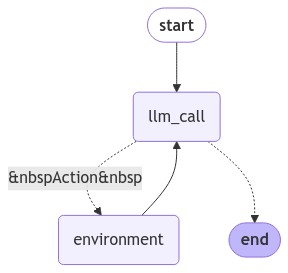

In [35]:
display(Image(agent.get_graph(xray=True).draw_mermaid_png()))

# 3.0. Testing

In [36]:
messages = [HumanMessage(content="Add 3 and 4.")]
messages = agent.invoke({"messages": messages})
for m in messages["messages"]:
    m.pretty_print()

================================ Human Message =================================

Add 3 and 4.
================================== Ai Message ==================================
Tool Calls:
  add (call_MZTHSXFuwVp6z7bnB4XEtGPp)
 Call ID: call_MZTHSXFuwVp6z7bnB4XEtGPp
  Args:
    a: 3
    b: 4
================================= Tool Message =================================

7
================================== Ai Message ==================================

The sum of 3 and 4 is 7.
